<a href="https://colab.research.google.com/github/ashrafsohail42003/Training-project/blob/main/Classification_Metrics_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
)


In [126]:
path = '/content/drive/MyDrive/AXSOSACADEMY/02-IntroML/Week07/Data/stroke.csv'
df = pd.read_csv(path)
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1192,Female,31,0,0,No,Govt_job,Rural,70.66,27.2,never smoked,0
1,77,Female,13,0,0,No,children,Rural,85.81,18.6,Unknown,0
2,59200,Male,18,0,0,No,Private,Urban,60.56,33.0,never smoked,0
3,24905,Female,65,0,0,Yes,Private,Urban,205.77,46.0,formerly smoked,1
4,24257,Male,4,0,0,No,children,Rural,90.42,16.2,Unknown,0
5,57210,Female,28,0,0,Yes,Private,Rural,131.80,30.3,never smoked,0
6,61103,Female,64,1,0,Yes,Self-employed,Urban,190.92,31.4,never smoked,0
7,6480,Male,62,0,0,No,Govt_job,Urban,93.55,31.7,never smoked,0
8,62983,Female,26,0,0,Yes,Private,Urban,138.02,20.3,smokes,0
9,50784,Male,63,0,0,Yes,Private,Rural,228.56,27.4,never smoked,1


In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1137 entries, 0 to 1136
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 1137 non-null   int64  
 1   gender             1137 non-null   object 
 2   age                1137 non-null   object 
 3   hypertension       1137 non-null   int64  
 4   heart_disease      1137 non-null   int64  
 5   ever_married       1137 non-null   object 
 6   work_type          1137 non-null   object 
 7   Residence_type     1137 non-null   object 
 8   avg_glucose_level  1137 non-null   float64
 9   bmi                1085 non-null   float64
 10  smoking_status     1137 non-null   object 
 11  stroke             1137 non-null   int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 106.7+ KB


In [128]:
df.describe()

,id,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,1137.000000,1137.000000,1137.000000,1137.000000,1085.000000,1137.000000
mean,36750.933157,0.118734,0.068602,107.664002,29.198065,0.120493
std,21112.281253,0.323617,0.252887,47.618723,7.669615,0.325680
min,77.000000,0.000000,0.000000,55.270000,11.300000,0.000000
25%,17986.000000,0.000000,0.000000,77.600000,24.100000,0.000000
50%,37479.000000,0.000000,0.000000,91.820000,28.500000,0.000000
75%,55410.000000,0.000000,0.000000,113.850000,33.200000,0.000000
max,72918.000000,1.000000,1.000000,266.590000,64.400000,1.000000


In [129]:
print(df['stroke'].value_counts(normalize=True))
print(df['gender'].value_counts(normalize=True))
print(df['hypertension'].value_counts(normalize=True))
print(df['heart_disease'].value_counts(normalize=True))
print(df['work_type'].value_counts(normalize=True))
print(df['avg_glucose_level'].value_counts(normalize=True))
print(df['Residence_type'].value_counts(normalize=True))
print(df['bmi'].value_counts(normalize=True))
print(df['smoking_status'].value_counts(normalize=True))

stroke
0    0.879507
1    0.120493
Name: proportion, dtype: float64
gender
Female    0.564644
Male      0.434477
Other     0.000880
Name: proportion, dtype: float64
hypertension
0    0.881266
1    0.118734
Name: proportion, dtype: float64
heart_disease
0    0.931398
1    0.068602
Name: proportion, dtype: float64
work_type
Private          0.591029
Self-employed    0.153034
children         0.129288
Govt_job         0.124890
Never_worked     0.001759
Name: proportion, dtype: float64
avg_glucose_level
92.14     0.002639
115.52    0.001759
203.81    0.001759
84.04     0.001759
74.96     0.001759
            ...   
190.13    0.000880
232.81    0.000880
100.09    0.000880
114.76    0.000880
165.36    0.000880
Name: proportion, Length: 1069, dtype: float64
Residence_type
Urban    0.516271
Rural    0.483729
Name: proportion, dtype: float64
bmi
27.3    0.010138
28.7    0.010138
26.4    0.010138
26.1    0.010138
31.4    0.010138
          ...   
38.6    0.000922
20.6    0.000922
36.4    0.00092

In [130]:
print(df['stroke'].value_counts(normalize=True).round(4))
for col in ['gender', 'hypertension', 'heart_disease','work_type', 'Residence_type', 'smoking_status']:
    print(f"\n {col} : ")
    print(df[col].value_counts(normalize=True).round(4))

stroke
0    0.8795
1    0.1205
Name: proportion, dtype: float64

 gender : 
gender
Female    0.5646
Male      0.4345
Other     0.0009
Name: proportion, dtype: float64

 hypertension : 
hypertension
0    0.8813
1    0.1187
Name: proportion, dtype: float64

 heart_disease : 
heart_disease
0    0.9314
1    0.0686
Name: proportion, dtype: float64

 work_type : 
work_type
Private          0.5910
Self-employed    0.1530
children         0.1293
Govt_job         0.1249
Never_worked     0.0018
Name: proportion, dtype: float64

 Residence_type : 
Residence_type
Urban    0.5163
Rural    0.4837
Name: proportion, dtype: float64

 smoking_status : 
smoking_status
never smoked       0.3659
Unknown            0.3096
formerly smoked    0.1803
smokes             0.1442
Name: proportion, dtype: float64


In [131]:
df = df.drop(columns=['id'])
df['smoking_status'] = df['smoking_status'].replace('Unknown', np.nan)
df = df[df['gender'] != 'Other']
df = df[df['work_type'] != 'Never_worked']

for col in ['age', 'avg_glucose_level', 'bmi']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Shape after cleaning: {df.shape}")
print(f"Missing values:\n{df.isna().sum()}")

Shape after cleaning: (1134, 11)
Missing values:
gender                 0
age                    1
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                   52
smoking_status       350
stroke                 0
dtype: int64


In [132]:
X = df.drop('stroke', axis=1)
y = df['stroke']

In [133]:
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
numerical_cols   = ['age', 'avg_glucose_level', 'bmi','hypertension', 'heart_disease']

In [134]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

In [135]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')),
])

In [136]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols),
])

In [137]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   DecisionTreeClassifier(random_state=42)),
])

In [138]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y,)

In [139]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'avg_glucose_level',
                                                   'bmi', 'hypertension',
                                                   'heart_disease']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'ever_married',
                                                   'work_type',
                                                   'Residence_type',
                                                   'smoking_status'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [140]:
def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8, 4),
                           normalize='true', cmap='Blues',
                           colorbar=False):

    report = classification_report(y_true, y_pred)
    header = "-" * 70
    print(header, f" Classification Metrics: {label}", header, sep='\n')
    print(report)

    fig, axes = plt.subplots(ncols=2, figsize=figsize)

    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        normalize=None, cmap='gist_gray',
        colorbar=colorbar, ax=axes[0],
    )
    axes[0].set_title("Raw Counts")

    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        normalize=normalize, cmap=cmap,
        colorbar=colorbar, ax=axes[1],
    )
    axes[1].set_title("Normalized Confusion Matrix")

    fig.tight_layout()
    plt.show()

    if output_dict:
        return classification_report(y_true, y_pred, output_dict=True)

def evaluate_classification(model, X_train, y_train, X_test, y_test,
                            figsize=(8, 4), normalize='true',
                            output_dict=False,
                            cmap_train='Blues', cmap_test='Reds',
                            colorbar=False):
    """Evaluates a classification pipeline on training and test data,
    printing classification reports and confusion matrices for both.
    """
    # Training data
    y_train_pred = model.predict(X_train)
    results_train = classification_metrics(
        y_train, y_train_pred,
        label='Training Data',
        output_dict=True,
        figsize=figsize,
        normalize=normalize,
        cmap=cmap_train,
        colorbar=colorbar,
    )

    print()

    # Test data
    y_test_pred = model.predict(X_test)
    results_test = classification_metrics(
        y_test, y_test_pred,
        label='Test Data',
        output_dict=True,
        figsize=figsize,
        normalize=normalize,
        cmap=cmap_test,
        colorbar=colorbar,
    )

    if output_dict:
        return {'train': results_train, 'test': results_test}

**1) Accuracy & assessment**
Accuracy is about **80%**, but it’s misleading due to class imbalance.
A dummy model predicting only “No Stroke” could get ~88%, so this model is actually worse.
It only detected **6 out of 27 stroke cases (~22%)**, which is very poor for medical use.

**2) False Positives**
About **10.6%** were false alarms (predicted stroke but actually no stroke).

**3) False Negatives**
About **9.25%** overall, but more importantly **~78% of real stroke cases were missed**.

**4) Metric to optimize**
Focus on **Recall for the stroke class**, with **F2-score** and **PR-AUC**.
Missing a stroke (FN) is far worse than a false alarm (FP).


In [141]:
y_proba = model.predict_proba(X_test)[:, 1]
print("Unique predicted probabilities:", np.unique(y_proba))

Unique predicted probabilities: [0. 1.]


----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.99      0.69      0.81       797
           1       0.30      0.95      0.45       110

    accuracy                           0.72       907
   macro avg       0.64      0.82      0.63       907
weighted avg       0.91      0.72      0.77       907



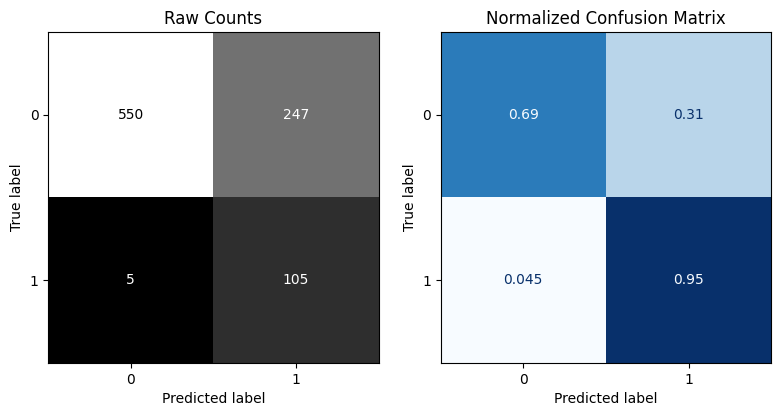


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.95      0.62      0.76       200
           1       0.22      0.78      0.34        27

    accuracy                           0.64       227
   macro avg       0.59      0.70      0.55       227
weighted avg       0.87      0.64      0.71       227



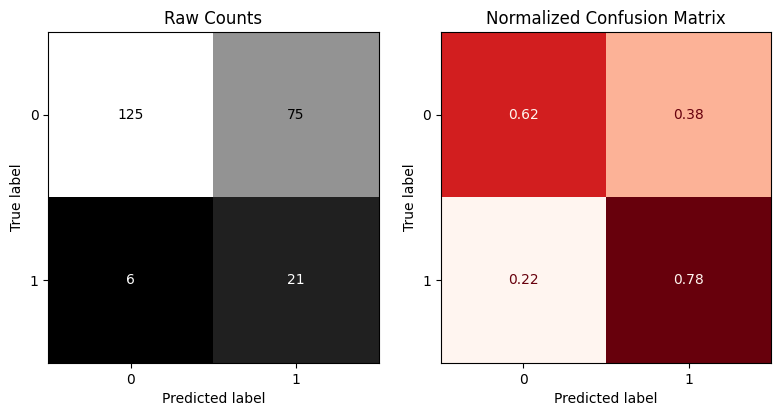

In [142]:
improved_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=42,
        max_depth=6,
        min_samples_leaf=20,
        class_weight='balanced',
    )),
])
improved_model.fit(X_train, y_train)

results_improved = evaluate_classification(
    improved_model, X_train, y_train, X_test, y_test,
    output_dict=True,
)

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.89      0.94       797
           1       0.54      0.89      0.67       110

    accuracy                           0.89       907
   macro avg       0.76      0.89      0.80       907
weighted avg       0.93      0.89      0.90       907



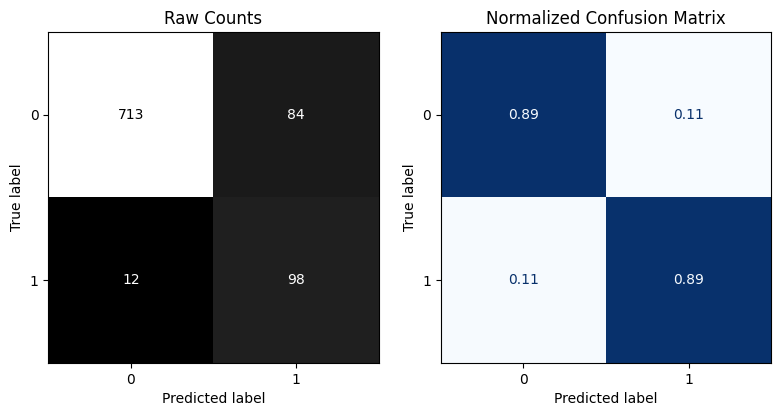


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.96      0.85      0.90       200
           1       0.40      0.70      0.51        27

    accuracy                           0.84       227
   macro avg       0.68      0.78      0.70       227
weighted avg       0.89      0.84      0.86       227



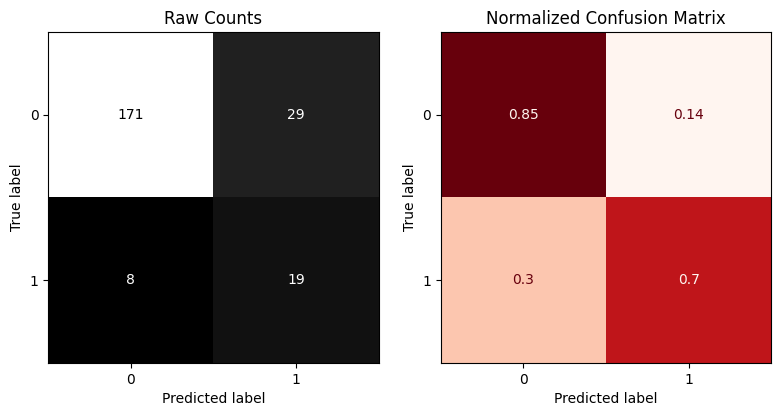

In [143]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=5,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42,
    )),
])
rf_model.fit(X_train, y_train)

results_rf = evaluate_classification(
    rf_model, X_train, y_train, X_test, y_test,
    output_dict=True,
)

Best threshold (F2-optimized on train): 0.445
  -> Train Precision: 0.477 | Train Recall: 0.964
----------------------------------------------------------------------
 Classification Metrics: Training Data — RF (threshold = 0.45)
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.99      0.85      0.92       797
           1       0.48      0.96      0.64       110

    accuracy                           0.87       907
   macro avg       0.74      0.91      0.78       907
weighted avg       0.93      0.87      0.89       907



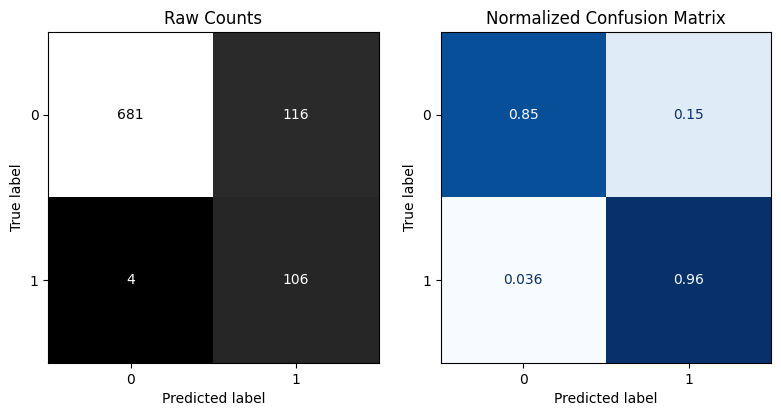


----------------------------------------------------------------------
 Classification Metrics: Test Data — RF (threshold = 0.45)
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.96      0.81      0.88       200
           1       0.34      0.74      0.47        27

    accuracy                           0.80       227
   macro avg       0.65      0.77      0.67       227
weighted avg       0.88      0.80      0.83       227



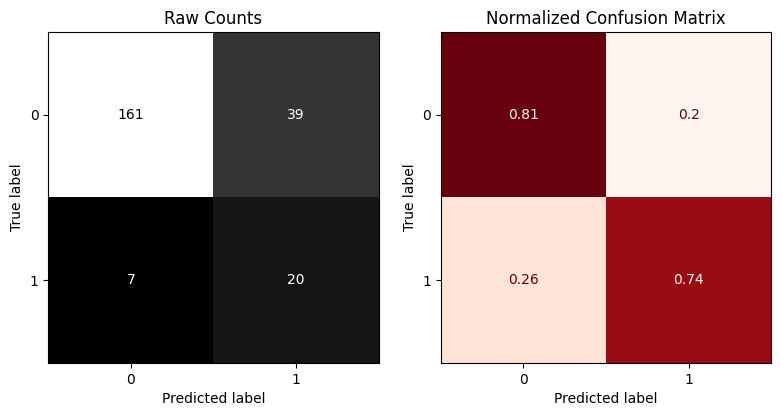

In [144]:
y_proba_train = rf_model.predict_proba(X_train)[:, 1]
y_proba_test  = rf_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_train, y_proba_train)
beta = 2
f2 = (1 + beta**2) * (precisions * recalls) / (beta**2 * precisions + recalls + 1e-12)
best_idx = np.argmax(f2[:-1])
best_threshold = thresholds[best_idx]

print(f"Best threshold (F2-optimized on train): {best_threshold:.3f}")
print(f"  -> Train Precision: {precisions[best_idx]:.3f} | Train Recall: {recalls[best_idx]:.3f}")
y_train_pred_tuned = (y_proba_train >= best_threshold).astype(int)
y_test_pred_tuned  = (y_proba_test  >= best_threshold).astype(int)

results_train_tuned = classification_metrics(
    y_train, y_train_pred_tuned,
    label=f'Training Data — RF (threshold = {best_threshold:.2f})',
    output_dict=True,
    cmap='Blues',
)

print()

results_test_tuned = classification_metrics(
    y_test, y_test_pred_tuned,
    label=f'Test Data — RF (threshold = {best_threshold:.2f})',
    output_dict=True,
    cmap='Reds',
)

results_rf_tuned = {'train': results_train_tuned, 'test': results_test_tuned}

In [145]:
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba_rf):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, y_proba_rf):.4f}")
print(f"F2-score: {fbeta_score(y_test, y_pred_tuned, beta=2):.4f}")

ROC-AUC : 0.8339
PR-AUC  : 0.3170
F2-score: 0.6213


In [146]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf_model, X, y, cv=cv,
                         scoring='average_precision', n_jobs=-1)
print(f"5-fold PR-AUC: {scores.mean():.4f} ± {scores.std():.4f}")

5-fold PR-AUC: 0.3575 ± 0.0399


[Text(0.47936893203883496, 0.9736842105263158, 'num__age <= 0.548\ngini = 0.213\nsamples = 907\nvalue = [797, 110]\nclass = No Stroke'),
 Text(0.18264563106796117, 0.9210526315789473, 'num__avg_glucose_level <= 2.906\ngini = 0.069\nsamples = 616\nvalue = [594, 22]\nclass = No Stroke'),
 Text(0.3310072815533981, 0.9473684210526316, 'True  '),
 Text(0.1729368932038835, 0.868421052631579, 'num__age <= -0.285\ngini = 0.066\nsamples = 615\nvalue = [594, 21]\nclass = No Stroke'),
 Text(0.11165048543689321, 0.8157894736842105, 'cat__smoking_status_smokes <= 0.5\ngini = 0.006\nsamples = 340\nvalue = [339, 1]\nclass = No Stroke'),
 Text(0.10194174757281553, 0.7631578947368421, 'gini = 0.0\nsamples = 298\nvalue = [298, 0]\nclass = No Stroke'),
 Text(0.12135922330097088, 0.7631578947368421, 'num__avg_glucose_level <= -0.642\ngini = 0.046\nsamples = 42\nvalue = [41, 1]\nclass = No Stroke'),
 Text(0.11165048543689321, 0.7105263157894737, 'num__avg_glucose_level <= -0.691\ngini = 0.165\nsamples = 11

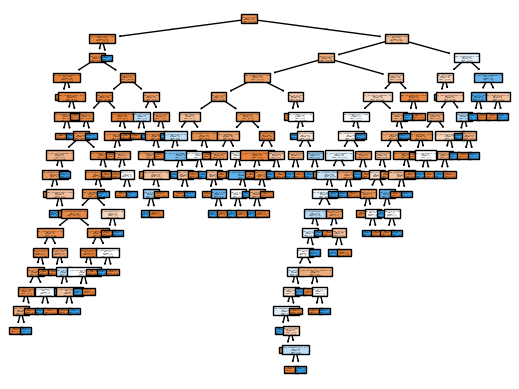

In [149]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
plot_tree(
    model.named_steps['classifier'],
    feature_names=feature_names,
    class_names=["No Stroke", "Stroke"],
    filled=True
)

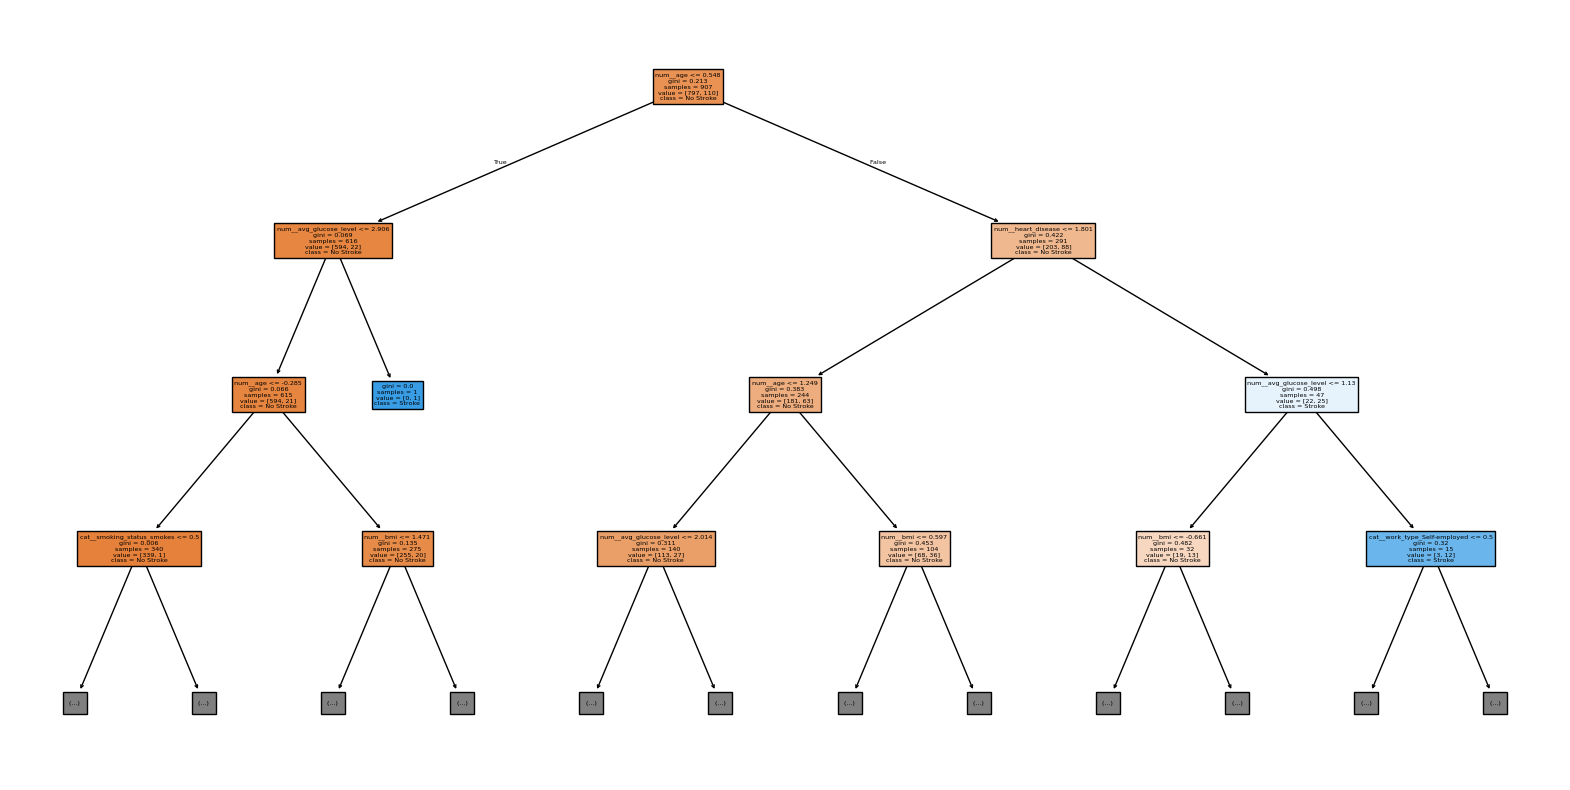

In [150]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(
    model.named_steps['classifier'],
    feature_names=model.named_steps['preprocessor'].get_feature_names_out(),
    class_names=["No Stroke", "Stroke"],
    filled=True,
    max_depth=3
)
plt.show()